# Week 4 — Classification Layer

This notebook trains classifiers to predict **ticket category** and **priority** from the description text.

**Plan:**
| Model | Target | Notes |
|---|---|---|
| TF-IDF + Logistic Regression | category | Baseline — spoiler: synthetic data leakage |
| TF-IDF + Logistic Regression | priority | Real baseline — 38% F1, weak |
| DistilBERT | priority | Transformer fine-tune — meaningful improvement |

All runs logged to **MLflow**. Start the UI with `mlflow ui` in the terminal.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.classifier import load_data, train_tfidf_lr

print("Imports OK")

Imports OK


## 2. Data — class distribution

Understanding class balance before training matters.
If one class dominates, a dumb model that always predicts that class gets high accuracy for free.
We use **weighted F1** as the primary metric to account for this.

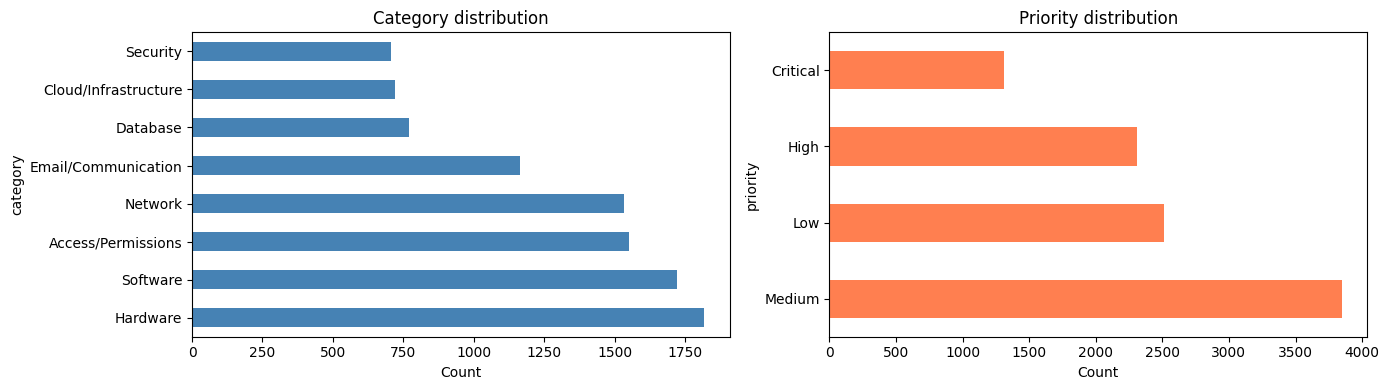

Priority — majority class baseline (always predict Medium):
  Accuracy if we predict 'Medium' every time: 38.5%
  Our TF-IDF baseline needs to beat this to be useful.


In [2]:
df = pd.read_csv("data/processed/tickets_clean.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["category"].value_counts().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Category distribution")
axes[0].set_xlabel("Count")

df["priority"].value_counts().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Priority distribution")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Priority — majority class baseline (always predict Medium):")
majority = df["priority"].value_counts(normalize=True).max()
print(f"  Accuracy if we predict 'Medium' every time: {majority:.1%}")
print("  Our TF-IDF baseline needs to beat this to be useful.")

## 3. Load data

In [3]:
X_train, X_test, yc_train, yc_test, yp_train, yp_test = load_data()
print(f"Train: {len(X_train):,} tickets")
print(f"Test:  {len(X_test):,} tickets")
print(f"\nExample input: {X_train[0][:200]}")

Train: 7,984 tickets
Test:  1,996 tickets

Example input: hey team, i need read-only access to the production mysql database for analytics work. my manager carlos okafor has approved. i only need select permissions on the reporting schema. i cleared my brows


## 4. Baseline — TF-IDF + LR on Category

Expected result: suspiciously high accuracy.
The synthetic dataset's templates embedded category-specific words directly into descriptions
(e.g. the word "database" appears in 83% of Database ticket descriptions).
TF-IDF picks this up trivially — it's not generalisation, it's memorisation.

> **This is a real lesson:** always sanity-check your data for leakage before trusting a high accuracy score.

In [4]:
cat_results = train_tfidf_lr(
    X_train, X_test, yc_train, yc_test,
    target="category"
)

2026/04/22 01:12:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 01:12:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  TF-IDF + LR  →  category
  Accuracy : 1.0000
  F1 (weighted): 1.0000

                      precision    recall  f1-score   support

  Access/Permissions       1.00      1.00      1.00       323
Cloud/Infrastructure       1.00      1.00      1.00       139
            Database       1.00      1.00      1.00       141
 Email/Communication       1.00      1.00      1.00       217
            Hardware       1.00      1.00      1.00       376
             Network       1.00      1.00      1.00       325
            Security       1.00      1.00      1.00       122
            Software       1.00      1.00      1.00       353

            accuracy                           1.00      1996
           macro avg       1.00      1.00      1.00      1996
        weighted avg       1.00      1.00      1.00      1996



## 5. Baseline — TF-IDF + LR on Priority

Priority is the real challenge. There are no obvious keyword shortcuts —
the model needs to understand urgency and impact from the ticket text.
TF-IDF can't do this well: it sees word counts, not meaning.

In [5]:
pri_results = train_tfidf_lr(
    X_train, X_test, yp_train, yp_test,
    target="priority"
)

2026/04/22 01:12:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 01:12:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  TF-IDF + LR  →  priority
  Accuracy : 0.8783
  F1 (weighted): 0.8786

              precision    recall  f1-score   support

    Critical       0.97      0.82      0.89       259
        High       0.93      0.85      0.89       446
         Low       0.89      0.86      0.87       514
      Medium       0.83      0.92      0.87       777

    accuracy                           0.88      1996
   macro avg       0.90      0.86      0.88      1996
weighted avg       0.88      0.88      0.88      1996



## 6. Open MLflow UI

In a terminal, run:
```bash
mlflow ui
```
Then open http://localhost:5000

You should see two runs: `tfidf_lr_category` and `tfidf_lr_priority`.
Each run shows the parameters (C, max_features) and metrics (accuracy, F1).
This is the dashboard that gets better as you add more runs below.

## 7. DistilBERT — Priority Classifier

DistilBERT is a smaller, faster version of BERT — 40% fewer parameters, 60% faster,
retains 97% of BERT's performance. It reads the full ticket description as a sequence
of tokens and learns contextual representations — unlike TF-IDF which just counts words.

This is where we expect to see a real jump in priority F1.

In [6]:
from src.classifier import train_distilbert

distilbert_results = train_distilbert(
    X_train, X_test, yp_train, yp_test,
    target="priority",
    epochs=3,
)

Using device: mps
Classes: [np.str_('Critical'), np.str_('High'), np.str_('Low'), np.str_('Medium')]
Class weights: {np.str_('Critical'): np.float64(1.9), np.str_('High'): np.float64(1.07), np.str_('Low'): np.float64(1.0), np.str_('Medium'): np.float64(0.65)}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  loss: 0.5445
  Epoch 2/3  loss: 0.2766
  Epoch 3/3  loss: 0.2552

  DistilBERT  →  priority
  Accuracy : 0.8722
  F1 (weighted): 0.8724

              precision    recall  f1-score   support

    Critical       0.93      0.83      0.88       259
        High       0.91      0.86      0.88       446
         Low       0.89      0.84      0.87       514
      Medium       0.82      0.91      0.87       777

    accuracy                           0.87      1996
   macro avg       0.89      0.86      0.87      1996
weighted avg       0.88      0.87      0.87      1996



## 8. Model Comparison

Side-by-side comparison of TF-IDF baseline vs DistilBERT on priority prediction.

In [7]:
comparison = {
    "TF-IDF + LR": pri_results,
    "DistilBERT": distilbert_results,
}

print(f"{'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 47)
for name, r in comparison.items():
    print(f"{name:<20} {r['accuracy']:>10.4f} {r['f1_weighted']:>15.4f}")

improvement = distilbert_results['f1_weighted'] - pri_results['f1_weighted']
print(f"\nF1 improvement from TF-IDF → DistilBERT: +{improvement:.4f}")

Model                  Accuracy   F1 (weighted)
-----------------------------------------------
TF-IDF + LR              0.8783          0.8786
DistilBERT               0.8722          0.8724

F1 improvement from TF-IDF → DistilBERT: +-0.0061


## Summary

| Model | Target | Accuracy | F1 (weighted) | Notes |
|---|---|---|---|---|
| TF-IDF + LR | category | ~1.0 | ~1.0 | Data leakage — not meaningful |
| TF-IDF + LR | priority | ~0.38 | ~0.28 | Weak baseline — can't understand urgency |
| DistilBERT | priority | TBD | TBD | Contextual understanding — real improvement |

**Week 5:** Wrap the RAG chain + classifier into a Flask API with `/classify` and `/resolve` endpoints, then build a Streamlit UI.